#**Emotion Detection using Face Dataset**

#Dataset link:https://www.kaggle.com/datasets/uwrfkaggler/ravdess-facial-landmark-tracking

#1. Ashiq Shaik (35033254)

In [ ]:
# =========================
# 1. Mount Google Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================
# 2. Install required package
# =========================
!pip -q install xgboost

In [ ]:
# =========================
# 3. Imports
# =========================
import os
import re
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import joblib

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# =========================
# 4. Set dataset folder path
# =========================
# Change this path if needed
dataset_dir = "/content/drive/MyDrive/Face dataset"

print("Dataset folder exists:", os.path.exists(dataset_dir))

Dataset folder exists: True


In [ ]:
# =========================
# 5. Find all CSV files recursively
# =========================
csv_files = glob.glob(os.path.join(dataset_dir, "**", "*.csv"), recursive=True)

print("Total CSV files found:", len(csv_files))
print("Sample files:")
for f in csv_files[:5]:
    print(f)


Total CSV files found: 2452
Sample files:
/content/drive/MyDrive/Face dataset/01-01-01-01-01-01-02.csv
/content/drive/MyDrive/Face dataset/01-01-01-01-01-01-01.csv
/content/drive/MyDrive/Face dataset/01-01-01-01-01-01-14.csv
/content/drive/MyDrive/Face dataset/01-01-01-01-01-02-09.csv
/content/drive/MyDrive/Face dataset/01-01-01-01-01-02-02.csv


In [ ]:
# =========================
# 6. Emotion mapping from filename
# RAVDESS-style code:
# 01 = neutral
# 02 = calm
# 03 = happy
# 04 = sad
# 05 = angry
# 06 = fear
# 07 = disgust
# 08 = surprised
# =========================
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fear",
    "07": "disgust",
    "08": "surprised"
}

def get_emotion_from_filename(filepath):
    filename = os.path.basename(filepath).replace(".csv", "")
    parts = filename.split("-")
    if len(parts) >= 3:
        emotion_code = parts[2]
        return emotion_map.get(emotion_code, "unknown")
    return "unknown"


#2. Mohammed Suleman (35049043)

In [ ]:
# =========================
# 7. Read one sample file
# =========================
sample_df = pd.read_csv(csv_files[0])
print("\nSample file shape:", sample_df.shape)
print("\nFirst 20 columns:")
print(sample_df.columns[:20].tolist())


Sample file shape: (109, 712)

First 20 columns:
['frame', 'timestamp', 'confidence', 'gaze_0_x', 'gaze_0_y', 'gaze_0_z', 'gaze_1_x', 'gaze_1_y', 'gaze_1_z', 'gaze_angle_x', 'gaze_angle_y', 'eye_lmk_x_0', 'eye_lmk_x_1', 'eye_lmk_x_2', 'eye_lmk_x_3', 'eye_lmk_x_4', 'eye_lmk_x_5', 'eye_lmk_x_6', 'eye_lmk_x_7', 'eye_lmk_x_8']


###A. Raw Sample File Visualization
Visualise Action Units, head pose, and gaze signals from a single video's CSV before any feature engineering.

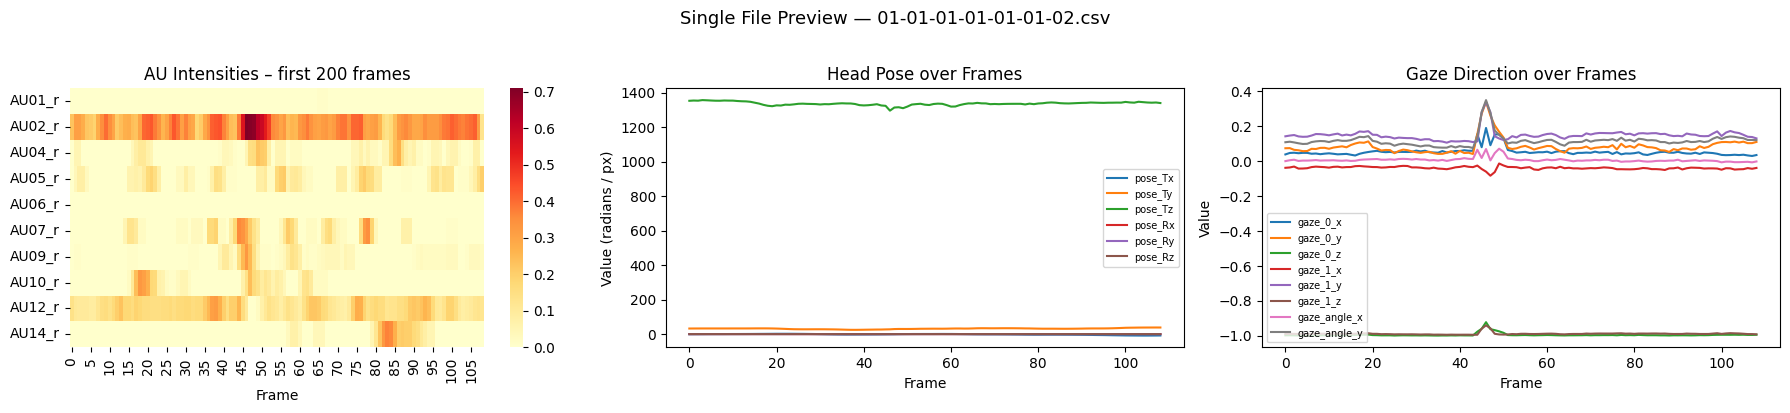

Sample file: 01-01-01-01-01-01-02.csv
Shape: (109, 712)  (frames × raw columns)
AU columns  : 10   |  Pose columns: 6  |  Gaze columns: 8


In [ ]:
# =========================
# [ADDED] A. Sample Dataset Visualization
# Visualise the raw feature columns of a single CSV file
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sample_df = pd.read_csv(csv_files[0])

# --- 1. Heatmap of first 200 frames × first 10 AU columns ---
au_cols = [c for c in sample_df.columns if c.startswith("AU")][:10]
pose_cols = [c for c in sample_df.columns if c.startswith("pose_")]
gaze_cols = [c for c in sample_df.columns if c.startswith("gaze_")]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# AU heatmap
if au_cols:
    sns.heatmap(
        sample_df[au_cols].head(200).T.astype(float),
        ax=axes[0], cmap="YlOrRd", cbar=True, yticklabels=True
    )
    axes[0].set_title("AU Intensities – first 200 frames")
    axes[0].set_xlabel("Frame")

# Pose over time
if pose_cols:
    sample_df[pose_cols].head(300).astype(float).plot(ax=axes[1])
    axes[1].set_title("Head Pose over Frames")
    axes[1].set_xlabel("Frame")
    axes[1].set_ylabel("Value (radians / px)")
    axes[1].legend(fontsize=7)

# Gaze over time
if gaze_cols:
    sample_df[gaze_cols].head(300).astype(float).plot(ax=axes[2])
    axes[2].set_title("Gaze Direction over Frames")
    axes[2].set_xlabel("Frame")
    axes[2].set_ylabel("Value")
    axes[2].legend(fontsize=7)

plt.suptitle(f"Single File Preview — {os.path.basename(csv_files[0])}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Sample file: {os.path.basename(csv_files[0])}")
print(f"Shape: {sample_df.shape}  (frames × raw columns)")
print(f"AU columns  : {len(au_cols)}   |  Pose columns: {len(pose_cols)}  |  Gaze columns: {len(gaze_cols)}")


In [ ]:
# =========================
# 8. Select useful columns
# Fast + strong features:
# gaze, pose, AU, confidence, success
# =========================
all_cols = sample_df.columns.tolist()

selected_cols = []
for col in all_cols:
    if (
        col.startswith("gaze_") or
        col.startswith("pose_") or
        col.startswith("AU")
    ):
        selected_cols.append(col)

if "confidence" in all_cols:
    selected_cols.append("confidence")

if "success" in all_cols:
    selected_cols.append("success")

print("\nSelected feature columns:", len(selected_cols))
print(selected_cols[:20])


Selected feature columns: 50
['gaze_0_x', 'gaze_0_y', 'gaze_0_z', 'gaze_1_x', 'gaze_1_y', 'gaze_1_z', 'gaze_angle_x', 'gaze_angle_y', 'pose_Tx', 'pose_Ty', 'pose_Tz', 'pose_Rx', 'pose_Ry', 'pose_Rz', 'AU01_r', 'AU02_r', 'AU04_r', 'AU05_r', 'AU06_r', 'AU07_r']


In [ ]:
# =========================
# 9. Feature extraction
# For each CSV file:
# mean, std, min, max, median
# =========================
def extract_features_from_csv(filepath, selected_cols):
    try:
        df = pd.read_csv(filepath)

        cols = [c for c in selected_cols if c in df.columns]
        df = df[cols].copy()

        for c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

        df = df.replace([np.inf, -np.inf], np.nan)
        df = df.fillna(df.median(numeric_only=True))
        df = df.fillna(0)

        feature_dict = {}

        for c in df.columns:
            values = df[c].values.astype(np.float32)

            feature_dict[f"{c}_mean"] = np.mean(values)
            feature_dict[f"{c}_std"] = np.std(values)
            feature_dict[f"{c}_min"] = np.min(values)
            feature_dict[f"{c}_max"] = np.max(values)
            feature_dict[f"{c}_median"] = np.median(values)

        return feature_dict

    except Exception as e:
        return None

In [ ]:
# =========================
# 10. Build dataset
# =========================
data_rows = []

for i, file_path in enumerate(csv_files):
    label = get_emotion_from_filename(file_path)
    if label == "unknown":
        continue

    feats = extract_features_from_csv(file_path, selected_cols)
    if feats is None:
        continue

    feats["label"] = label
    feats["file_name"] = os.path.basename(file_path)
    feats["full_path"] = file_path
    data_rows.append(feats)

    if (i + 1) % 200 == 0:
        print(f"Processed {i+1}/{len(csv_files)} files")

dataset_df = pd.DataFrame(data_rows)

print("\nFinal dataset shape:", dataset_df.shape)
print("\nClass counts:")
print(dataset_df["label"].value_counts())

Processed 200/2452 files
Processed 400/2452 files
Processed 600/2452 files
Processed 800/2452 files
Processed 1000/2452 files
Processed 1200/2452 files
Processed 1400/2452 files
Processed 1600/2452 files
Processed 1800/2452 files
Processed 2000/2452 files
Processed 2200/2452 files
Processed 2400/2452 files

Final dataset shape: (2452, 253)

Class counts:
label
calm         376
happy        376
sad          376
angry        376
fear         376
disgust      192
surprised    192
neutral      188
Name: count, dtype: int64


###EDA
Exploratory analysis of the fully built feature matrix — class balance, feature distributions, and AU correlations.

Dataset shape: (2452, 253)

Missing values: 0

Class distribution:
label
calm         376
happy        376
sad          376
angry        376
fear         376
disgust      192
surprised    192
neutral      188
Name: count, dtype: int64


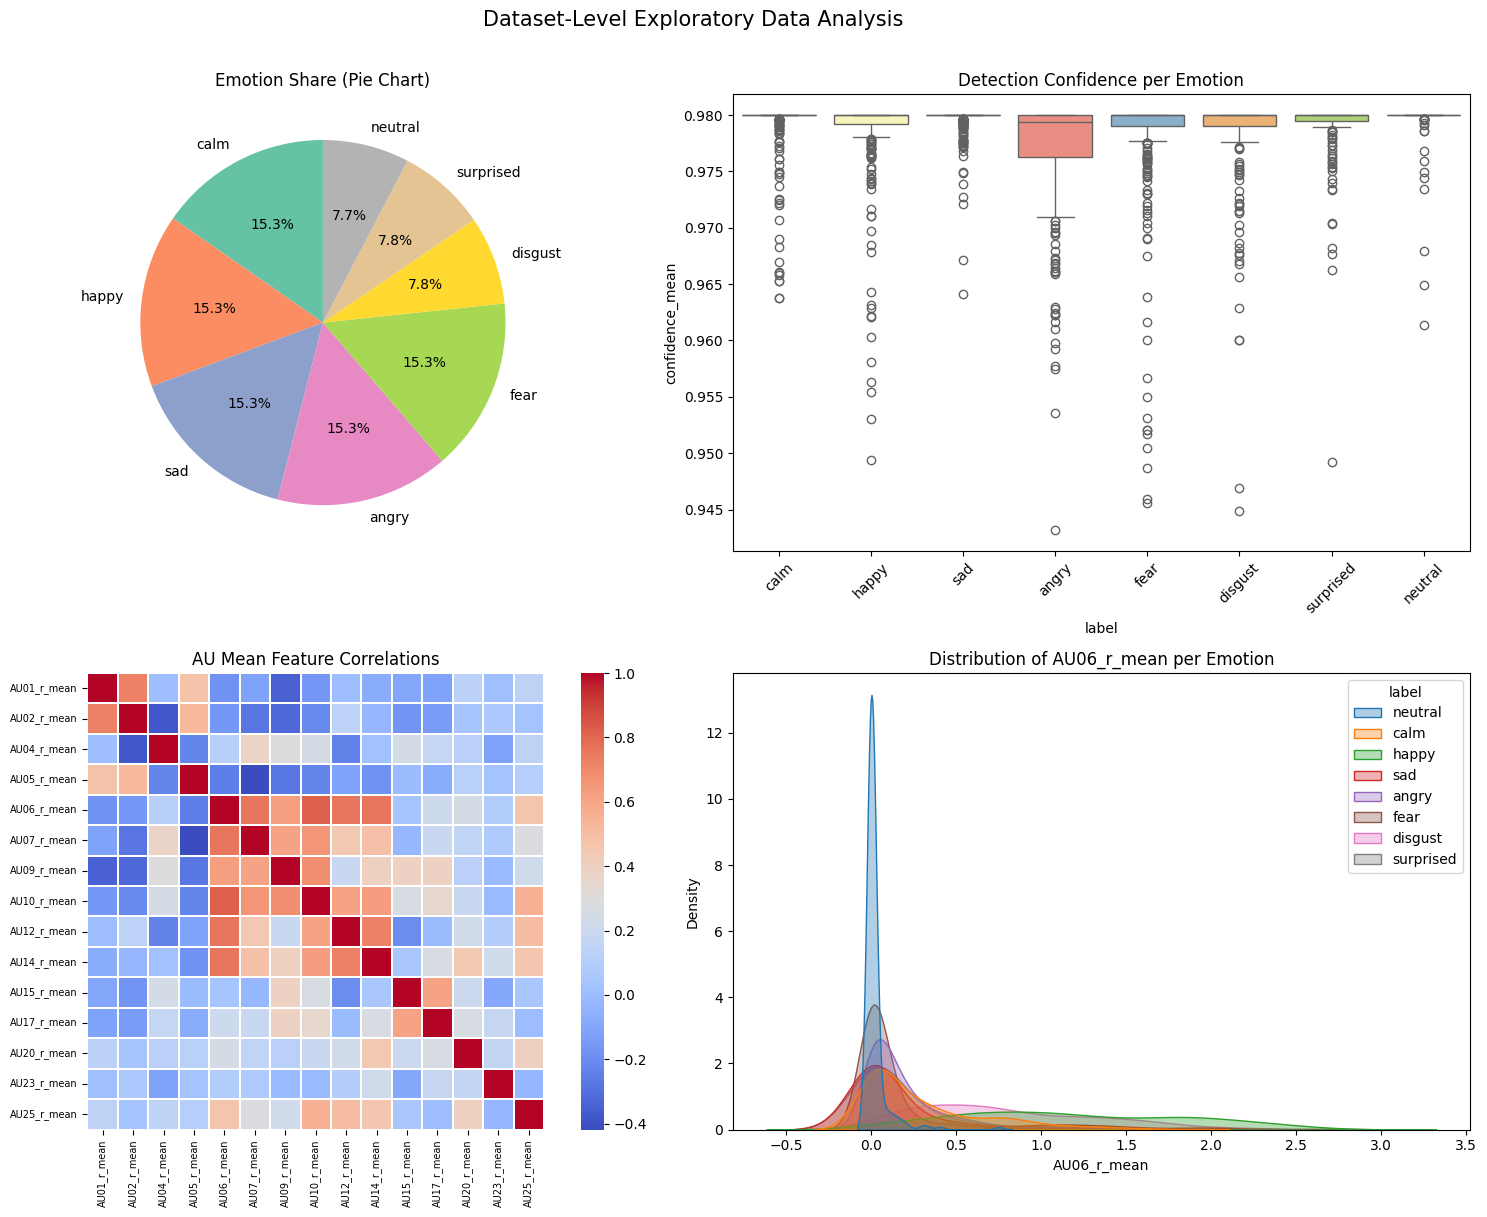

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("Dataset shape:", dataset_df.shape)
print("\nMissing values:", dataset_df.isnull().sum().sum())
print("\nClass distribution:")
print(dataset_df["label"].value_counts())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1 ─ Pie chart of emotion distribution
counts = dataset_df["label"].value_counts()
axes[0, 0].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
               startangle=90, colors=sns.color_palette("Set2", len(counts)))
axes[0, 0].set_title("Emotion Share (Pie Chart)")

# 2 ─ Box plot: confidence_mean by emotion
if "confidence_mean" in dataset_df.columns:
    sns.boxplot(data=dataset_df, x="label", y="confidence_mean", ax=axes[0, 1],
                palette="Set3", order=counts.index)
    axes[0, 1].set_title("Detection Confidence per Emotion")
    axes[0, 1].tick_params(axis="x", rotation=45)

# 3 ─ Correlation heatmap of top 15 AU mean features
au_mean_cols = [c for c in dataset_df.columns if c.startswith("AU") and c.endswith("_mean")][:15]
if len(au_mean_cols) >= 2:
    corr = dataset_df[au_mean_cols].astype(float).corr()
    sns.heatmap(corr, ax=axes[1, 0], cmap="coolwarm", annot=False, fmt=".1f",
                linewidths=0.3, square=True)
    axes[1, 0].set_title("AU Mean Feature Correlations")
    axes[1, 0].tick_params(axis="x", rotation=90, labelsize=7)
    axes[1, 0].tick_params(axis="y", labelsize=7)

# 4 ─ Distribution of a key AU (AU06 = cheek raise / smiling)
key_au = next((c for c in dataset_df.columns if "AU06" in c and c.endswith("_mean")), None)
if key_au:
    sns.kdeplot(data=dataset_df, x=key_au, hue="label", ax=axes[1, 1],
                fill=True, alpha=0.35, palette="tab10", common_norm=False)
    axes[1, 1].set_title(f"Distribution of {key_au} per Emotion")
    axes[1, 1].set_xlabel(key_au)

plt.suptitle("Dataset-Level Exploratory Data Analysis", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


#3. Pamulapati Mahesh Babu (35045493)

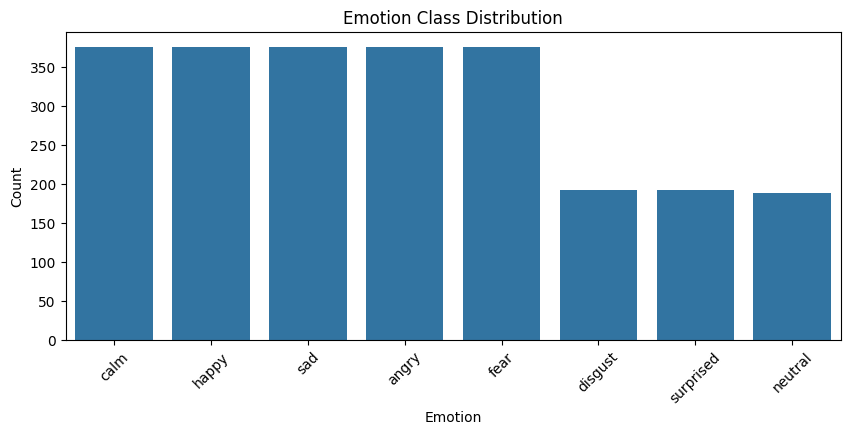

In [ ]:
# =========================
# 11. Plot class distribution
# =========================
plt.figure(figsize=(10, 4))
sns.countplot(x="label", data=dataset_df, order=dataset_df["label"].value_counts().index)
plt.title("Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### C. Per-Emotion AU Radar Chart
Radar chart showing which Action Units are most activated for each emotion class.

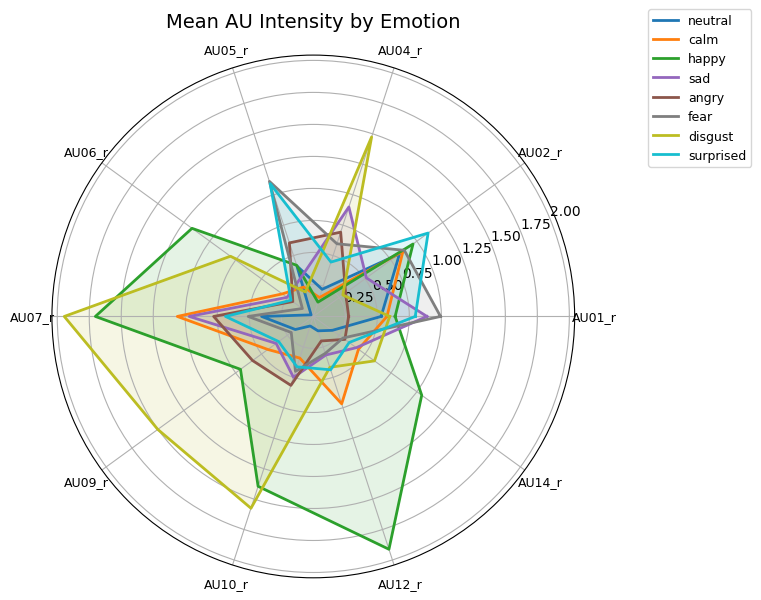

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

au_mean_cols = [c for c in dataset_df.columns if c.startswith("AU") and c.endswith("_mean")][:10]
emotions     = dataset_df["label"].unique()

emotion_au   = dataset_df.groupby("label")[au_mean_cols].mean()
labels       = [c.replace("_mean", "") for c in au_mean_cols]
N            = len(labels)
angles       = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles      += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
palette = plt.cm.get_cmap("tab10", len(emotions))

for i, emotion in enumerate(emotions):
    values = emotion_au.loc[emotion].tolist() if emotion in emotion_au.index else [0]*N
    values += values[:1]
    ax.plot(angles, values, label=emotion, color=palette(i), linewidth=2)
    ax.fill(angles, values, alpha=0.12, color=palette(i))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_title("Mean AU Intensity by Emotion", fontsize=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
# =========================
# 12. Prepare X and y
# =========================
X = dataset_df.drop(columns=["label", "file_name", "full_path"])
y = dataset_df["label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nEncoded classes:")
print(list(label_encoder.classes_))


Encoded classes:
['angry', 'calm', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprised']


In [ ]:
# =========================
# 13. Train/Val/Test split
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (1568, 250)
Validation shape: (393, 250)
Test shape: (491, 250)


###D. t-SNE Feature Space Embedding
t-SNE projection of all 468 engineered features into 2 dimensions to visualise emotion separability before training.

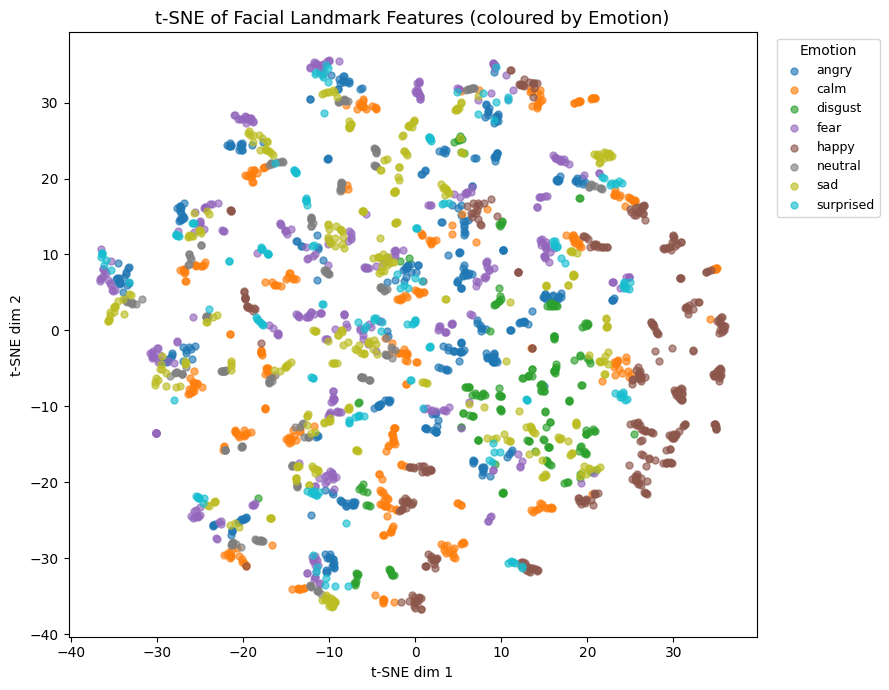

In [ ]:

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

feat_cols = [c for c in dataset_df.columns if c not in ["label","file_name","full_path"]]
X_vis = dataset_df[feat_cols].fillna(0).values
y_vis = dataset_df["label"].values

# Scale → PCA to 50 dims → t-SNE to 2 dims
X_scaled = StandardScaler().fit_transform(X_vis)
X_pca    = PCA(n_components=min(50, X_scaled.shape[1]), random_state=42).fit_transform(X_scaled)
X_tsne   = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500).fit_transform(X_pca)

palette  = plt.cm.get_cmap("tab10", len(np.unique(y_vis)))
fig, ax  = plt.subplots(figsize=(9, 7))

for i, emotion in enumerate(np.unique(y_vis)):
    mask = y_vis == emotion
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               label=emotion, alpha=0.65, s=25, color=palette(i))

ax.set_title("t-SNE of Facial Landmark Features (coloured by Emotion)", fontsize=13)
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.legend(title="Emotion", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
# =========================
# 14. Define fast strong models
# =========================
models = {
    "ExtraTrees": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", ExtraTreesClassifier(
            n_estimators=250,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(
            n_estimators=180,
            max_depth=6,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1
        ))
    ])
}

#4.Nikhilesh Andole (35040343)


Training ExtraTrees...
ExtraTrees Validation Accuracy: 0.8855

Training RandomForest...
RandomForest Validation Accuracy: 0.8677

Training XGBoost...
XGBoost Validation Accuracy: 0.8626

Model Comparison:
          Model  Validation Accuracy
0    ExtraTrees             0.885496
1  RandomForest             0.867684
2       XGBoost             0.862595


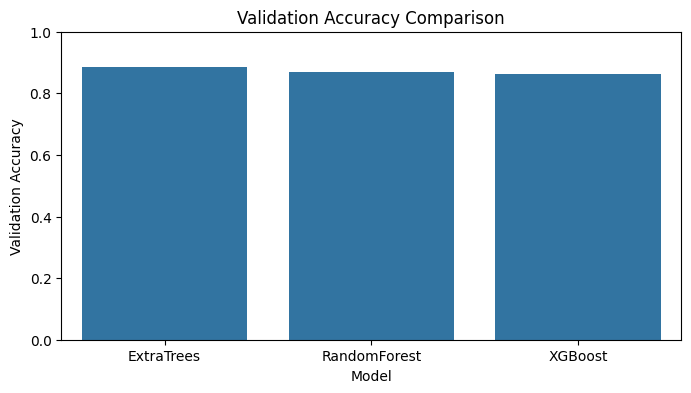

In [ ]:
# =========================
# 15. Train models and compare
# =========================
results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)

    results.append((name, val_acc))
    print(f"{name} Validation Accuracy: {val_acc:.4f}")

results_df = pd.DataFrame(results, columns=["Model", "Validation Accuracy"])
results_df = results_df.sort_values(by="Validation Accuracy", ascending=False)

print("\nModel Comparison:")
print(results_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Model", y="Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.ylim(0, 1)
plt.show()


In [ ]:
# =========================
# 16. Select best model
# =========================
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"\nBest model selected: {best_model_name}")

# Retrain on full train+validation data
best_model.fit(X_train_full, y_train_full)


Best model selected: ExtraTrees


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 ExtraTreesClassifier(n_estimators=250, n_jobs=-1,
                                      random_state=42))])

#5.Rajagopala Rao Bandaru (35050526)

In [ ]:
# =========================
# 17. Test evaluation
# =========================
y_test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\nFinal Test Accuracy ({best_model_name}): {test_acc:.4f}")

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=label_encoder.classes_
))


Final Test Accuracy (ExtraTrees): 0.8921

Classification Report:

              precision    recall  f1-score   support

       angry       0.89      0.97      0.93        75
        calm       0.86      0.95      0.90        75
     disgust       0.90      0.92      0.91        39
        fear       0.88      0.93      0.90        75
       happy       0.91      0.96      0.94        75
     neutral       0.86      0.84      0.85        38
         sad       0.94      0.84      0.89        75
   surprised       0.91      0.54      0.68        39

    accuracy                           0.89       491
   macro avg       0.89      0.87      0.87       491
weighted avg       0.89      0.89      0.89       491



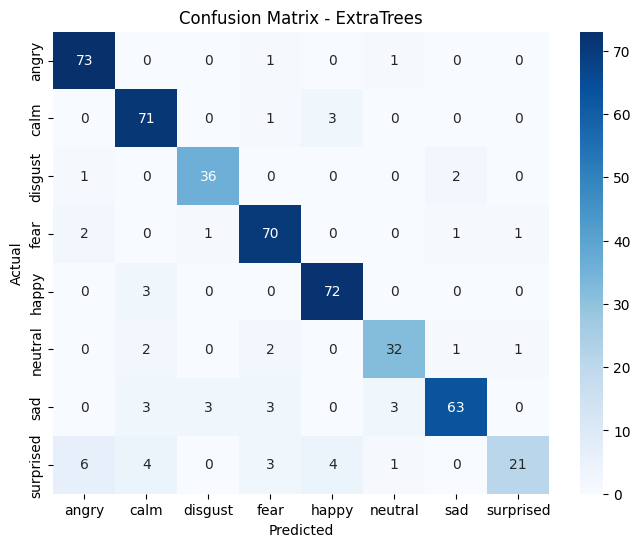

In [ ]:
# =========================
# 18. Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Top 20 Important Features:
           Feature  Importance
199  AU12_c_median    0.023560
110    AU12_r_mean    0.014591
195    AU12_c_mean    0.014543
169  AU04_c_median    0.012734
165    AU04_c_mean    0.012676
179  AU06_c_median    0.012586
114  AU12_r_median    0.012004
194  AU10_c_median    0.010846
168     AU04_c_max    0.010725
190    AU10_c_mean    0.009907
188     AU09_c_max    0.009890
175    AU06_c_mean    0.009214
108     AU10_r_max    0.008364
120    AU15_r_mean    0.008051
154  AU45_r_median    0.007808
193     AU10_c_max    0.007686
113     AU12_r_max    0.007615
83      AU04_r_max    0.007576
150    AU45_r_mean    0.007485
124  AU15_r_median    0.007430


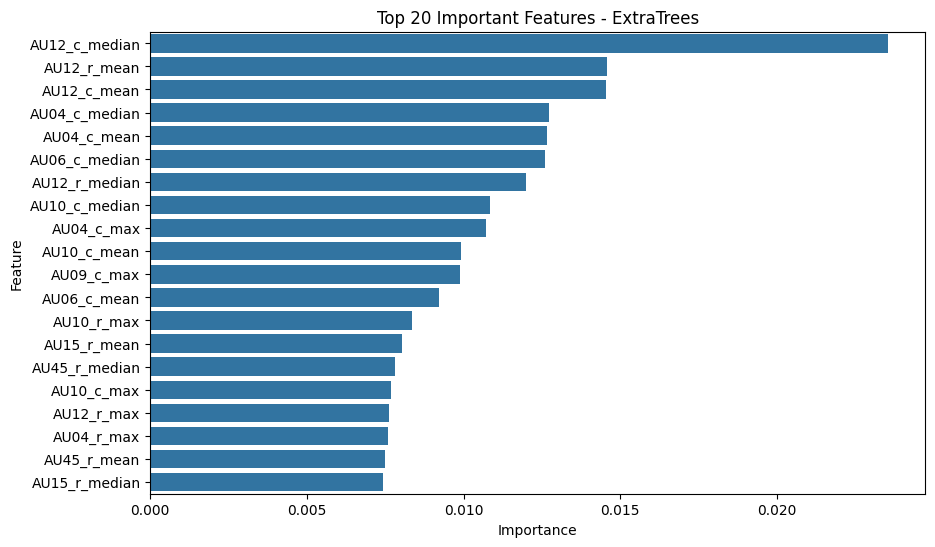

In [ ]:
# =========================
# 19. Feature importance
# =========================
clf = best_model.named_steps["clf"]

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
    feature_names = X.columns

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).head(20)

    print("\nTop 20 Important Features:")
    print(importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x="Importance", y="Feature")
    plt.title(f"Top 20 Important Features - {best_model_name}")
    plt.show()


In [ ]:
# =========================
# 20. Show sample predictions
# =========================
X_test_df = X_test.copy()
X_test_df["Actual"] = label_encoder.inverse_transform(y_test)
X_test_df["Predicted"] = label_encoder.inverse_transform(y_test_pred)

sample_results = X_test_df[["Actual", "Predicted"]].sample(min(15, len(X_test_df)), random_state=42)
print("\nSample Predictions:")
display(sample_results)


Sample Predictions:


,Actual,Predicted
1830,happy,happy
1452,surprised,happy
1812,happy,happy
2072,angry,angry
2000,sad,sad
1109,disgust,disgust
1730,calm,calm
1704,happy,happy
418,happy,happy
2198,angry,angry


In [ ]:
# =========================
# 21. Save best model
# =========================
save_dir = "/content/drive/MyDrive/face_csv_emotion_model"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "best_face_emotion_model.pkl")
label_path = os.path.join(save_dir, "label_encoder.pkl")
feature_path = os.path.join(save_dir, "feature_columns.pkl")

joblib.dump(best_model, model_path)
joblib.dump(label_encoder, label_path)
joblib.dump(list(X.columns), feature_path)

print("\nSaved files:")
print(model_path)
print(label_path)
print(feature_path)


Saved files:
/content/drive/MyDrive/face_csv_emotion_model/best_face_emotion_model.pkl
/content/drive/MyDrive/face_csv_emotion_model/label_encoder.pkl
/content/drive/MyDrive/face_csv_emotion_model/feature_columns.pkl


In [ ]:
# =========================
# 22. Predict one CSV file
# =========================
def predict_single_csv(file_path, model_path, label_path, feature_path, selected_cols):
    model = joblib.load(model_path)
    label_encoder = joblib.load(label_path)
    feature_columns = joblib.load(feature_path)

    feats = extract_features_from_csv(file_path, selected_cols)
    row = pd.DataFrame([feats])

    for c in feature_columns:
        if c not in row.columns:
            row[c] = 0

    row = row[feature_columns]

    pred_encoded = model.predict(row)[0]
    pred_label = label_encoder.inverse_transform([pred_encoded])[0]

    confidence = None
    if hasattr(model.named_steps["clf"], "predict_proba"):
        probs = model.predict_proba(row)[0]
        confidence = float(np.max(probs))

    return pred_label, confidence

# Example prediction on first file
example_file = csv_files[0]
pred_label, confidence = predict_single_csv(
    example_file,
    model_path,
    label_path,
    feature_path,
    selected_cols
)

print("\nExample file prediction:")
print("File:", example_file)
print("Predicted emotion:", pred_label)
if confidence is not None:
    print("Confidence:", round(confidence, 4))


Example file prediction:
File: /content/drive/MyDrive/Face dataset/01-01-01-01-01-01-02.csv
Predicted emotion: neutral
Confidence: 0.52


###E. Sample Prediction Showcase
Run the best trained model on 10 randomly selected test samples, display a confidence bar chart, and break down the probability distribution for the first sample.

#    Actual       Predicted    Confidence  Match?
-------------------------------------------------------
1    calm         calm              69.2%  ✓
2    happy        happy             94.8%  ✓
3    disgust      disgust           22.0%  ✓
4    surprised    surprised         28.0%  ✓
5    neutral      neutral           58.8%  ✓
6    angry        angry             32.0%  ✓
7    angry        angry             58.4%  ✓
8    fear         fear              65.6%  ✓
9    sad          sad               75.2%  ✓
10   fear         fear              84.0%  ✓


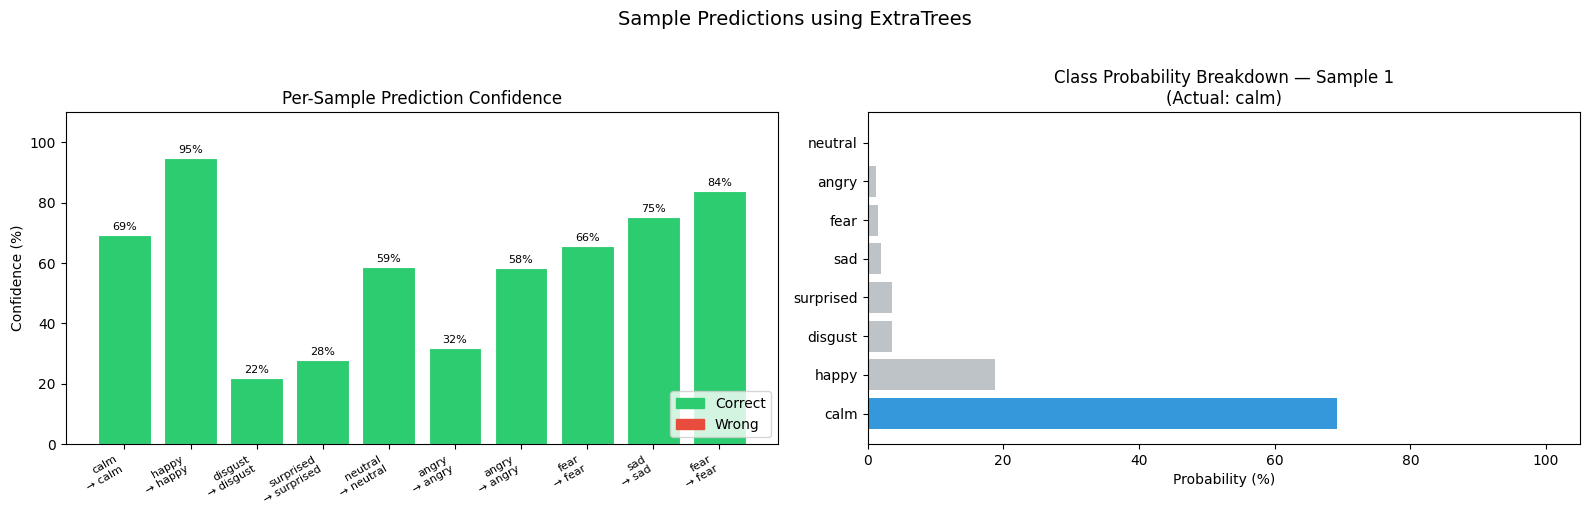


Sample accuracy: 10/10 = 100%
Mean confidence: 58.8%


In [ ]:

import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── pick up to 10 random files from the test set ──────────
test_indices = random.sample(range(len(X_test)), min(10, len(X_test)))
X_sample     = X_test.iloc[test_indices]
y_actual     = label_encoder.inverse_transform(y_test[test_indices])
y_pred_raw   = best_model.predict(X_sample)
y_predicted  = label_encoder.inverse_transform(y_pred_raw)

# ── confidence scores ─────────────────────────────────────
clf_step = best_model.named_steps["clf"]
if hasattr(clf_step, "predict_proba"):
    proba    = best_model.predict_proba(X_sample)
    conf     = np.max(proba, axis=1)
else:
    conf     = np.ones(len(y_predicted))

# ── tabular summary ──────────────────────────────────────
print(f"{'#':<4} {'Actual':<12} {'Predicted':<12} {'Confidence':>10}  Match?")
print("-" * 55)
for i, (act, pred, c) in enumerate(zip(y_actual, y_predicted, conf)):
    match = "✓" if act == pred else "✗"
    print(f"{i+1:<4} {act:<12} {pred:<12} {c*100:>9.1f}%  {match}")

# ── bar chart: confidence per sample ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ["#2ecc71" if a == p else "#e74c3c" for a, p in zip(y_actual, y_predicted)]
x_pos  = range(len(y_actual))

bars = axes[0].bar(x_pos, conf * 100, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(
    [f"{a}\n→ {p}" for a, p in zip(y_actual, y_predicted)],
    fontsize=8, rotation=30, ha="right"
)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel("Confidence (%)")
axes[0].set_title("Per-Sample Prediction Confidence")
for bar, c in zip(bars, conf):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{c*100:.0f}%", ha="center", va="bottom", fontsize=8)
correct_patch  = mpatches.Patch(color="#2ecc71", label="Correct")
wrong_patch    = mpatches.Patch(color="#e74c3c", label="Wrong")
axes[0].legend(handles=[correct_patch, wrong_patch], loc="lower right")

# ── probability breakdown for the first sample ────────────
if hasattr(clf_step, "predict_proba"):
    first_proba = best_model.predict_proba(X_sample.iloc[[0]])[0]
    emotion_labels = label_encoder.classes_
    sorted_idx  = np.argsort(first_proba)[::-1]
    axes[1].barh(
        [emotion_labels[j] for j in sorted_idx],
        [first_proba[j] * 100 for j in sorted_idx],
        color=["#3498db" if emotion_labels[j] == y_actual[0] else "#bdc3c7"
               for j in sorted_idx]
    )
    axes[1].set_xlabel("Probability (%)")
    axes[1].set_title(f"Class Probability Breakdown — Sample 1\n(Actual: {y_actual[0]})")
    axes[1].set_xlim(0, 105)

plt.suptitle(f"Sample Predictions using {best_model_name}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── overall mini report ───────────────────────────────────
n_correct = sum(a == p for a, p in zip(y_actual, y_predicted))
print(f"\nSample accuracy: {n_correct}/{len(y_actual)} = {n_correct/len(y_actual)*100:.0f}%")
print(f"Mean confidence: {np.mean(conf)*100:.1f}%")


#**Emotion detection using Speech**

#Dataset Link: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio

#1) Nikhilesh Andole (35040343)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# -----------------------------
# 1. Install required libraries
# -----------------------------
!pip install -q librosa soundfile tensorflow scikit-learn seaborn

In [ ]:
# -----------------------------
# 2. Imports
# -----------------------------
# -----------------------
# System libraries
# -----------------------
import os
import zipfile
import shutil
import warnings
warnings.filterwarnings("ignore")

# -----------------------
# Data handling
# -----------------------
import numpy as np
import pandas as pd

# -----------------------
# Audio processing
# -----------------------
import librosa
import librosa.display
import soundfile as sf

# -----------------------
# Visualization
# -----------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------
# Machine learning tools
# -----------------------
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

# -----------------------
# TensorFlow / Deep Learning
# -----------------------
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    Dropout,
    Bidirectional,
    LSTM,
    Dense,
    GlobalAveragePooling1D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

# -----------------------
# Print versions (optional)
# -----------------------
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

TensorFlow version: 2.19.0
NumPy version: 2.0.2
Pandas version: 2.2.2


In [ ]:
# -----------------------------
# 3. GPU check
# -----------------------------
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU detected:", gpus)
else:
    print("No GPU detected. In Colab: Runtime -> Change runtime type -> GPU")

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# -----------------------------
# 4. Path define from drive
# -----------------------------

EXTRACT_DIR = "/content/drive/MyDrive/RAVDESS Emotional dataset"

In [ ]:
# -----------------------------
# 5. RAVDESS label mapping
# Filename format:
# 03-01-06-01-02-01-12.wav
# 3rd part = emotion ID
# -----------------------------
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}


In [ ]:
# -----------------------------
# 6. Build dataframe from files
# -----------------------------
data = []

for root, dirs, files in os.walk(EXTRACT_DIR):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)

            parts = file.replace(".wav", "").split("-")
            if len(parts) == 7:
                emotion_id = parts[2]
                actor_id = parts[6]

                emotion = emotion_map.get(emotion_id, "unknown")

                data.append({
                    "path": file_path,
                    "file_name": file,
                    "emotion_id": emotion_id,
                    "emotion": emotion,
                    "actor": actor_id
                })

df = pd.DataFrame(data)

print("Total files:", len(df))
print(df.head())

Total files: 2640
                                                path  \
0  /content/drive/MyDrive/RAVDESS Emotional datas...   
1  /content/drive/MyDrive/RAVDESS Emotional datas...   
2  /content/drive/MyDrive/RAVDESS Emotional datas...   
3  /content/drive/MyDrive/RAVDESS Emotional datas...   
4  /content/drive/MyDrive/RAVDESS Emotional datas...   

                  file_name emotion_id    emotion actor  
0  03-01-03-01-02-01-09.wav         03      happy    09  
1  03-01-04-02-01-02-09.wav         04        sad    09  
2  03-01-06-02-01-01-09.wav         06    fearful    09  
3  03-01-08-02-02-02-09.wav         08  surprised    09  
4  03-01-07-01-02-02-09.wav         07    disgust    09  


###Single Audio File Visualisation
Listen to what the raw data looks like — waveform, spectrogram, and MFCC for one sample from each emotion.

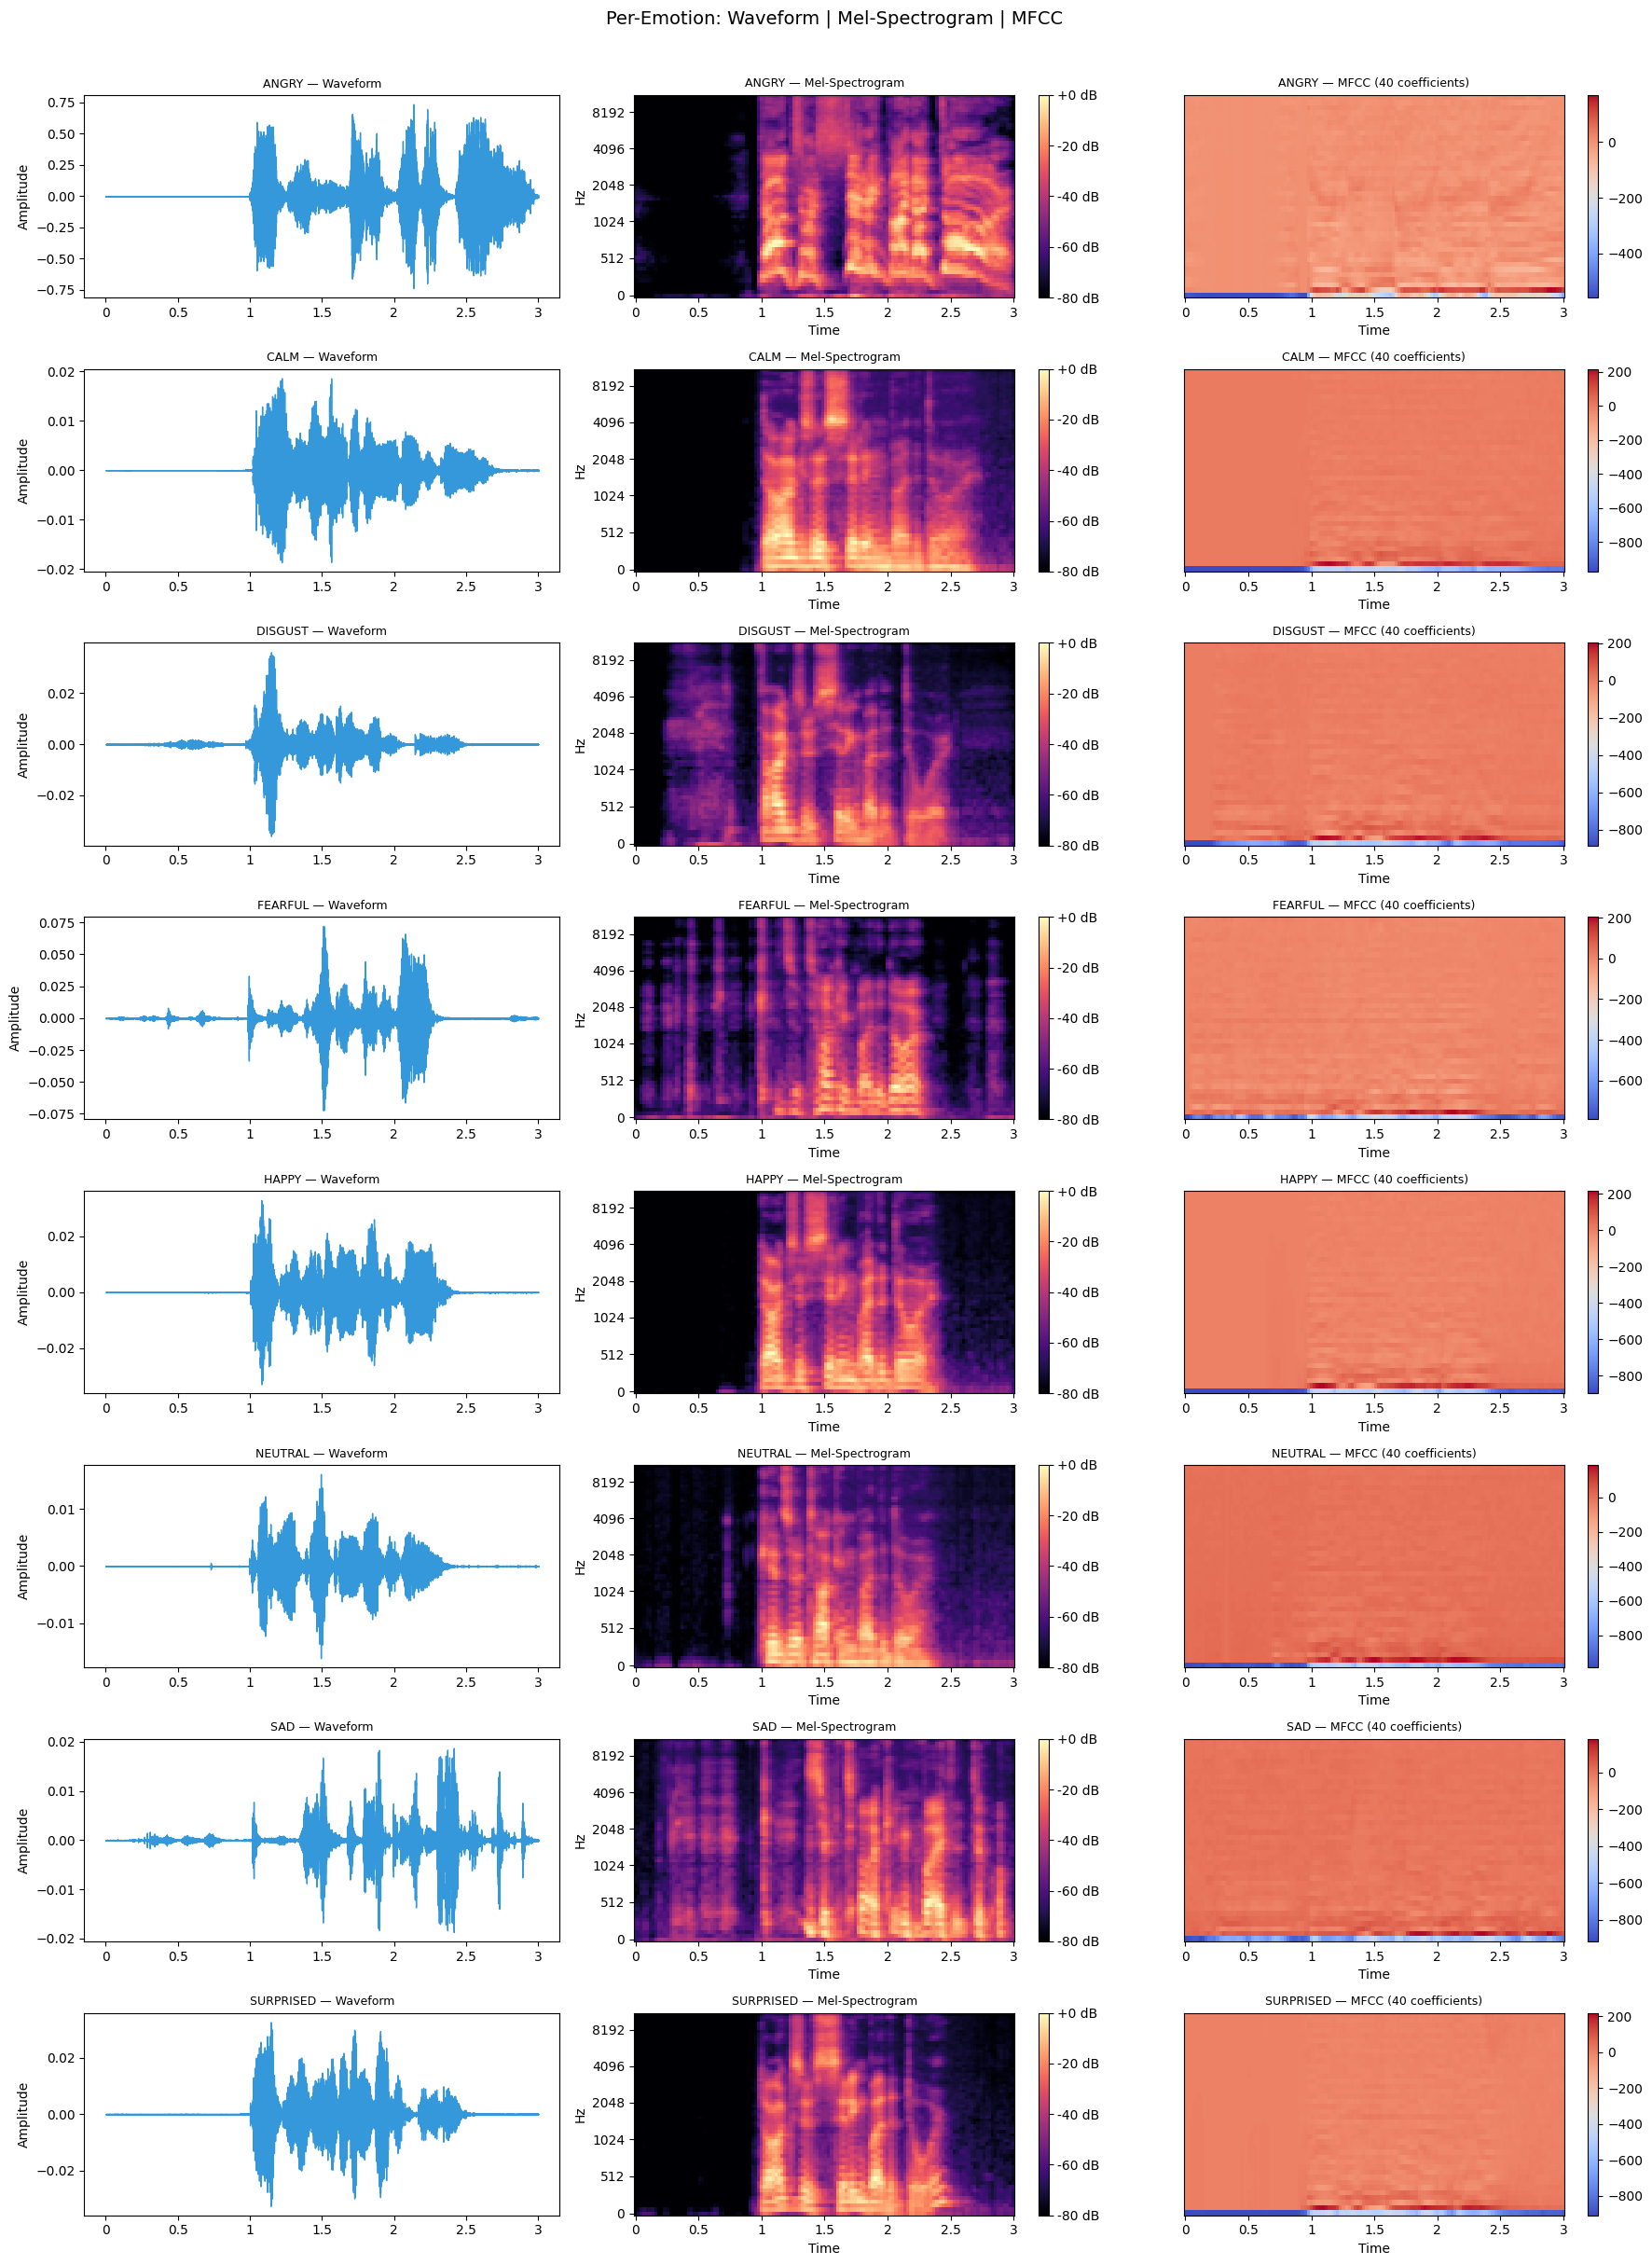

Visualised 8 emotion classes.


In [ ]:

import librosa, librosa.display, matplotlib.pyplot as plt, numpy as np

# Pick one file per emotion for the grid
sample_rows = df.groupby("emotion").first().reset_index()

fig, axes = plt.subplots(len(sample_rows), 3, figsize=(18, 3 * len(sample_rows)))
fig.suptitle("Per-Emotion: Waveform | Mel-Spectrogram | MFCC", fontsize=14, y=1.01)

for i, (_, row) in enumerate(sample_rows.iterrows()):
    signal, sr = librosa.load(row["path"], sr=22050, duration=3.0)

    # Waveform
    ax0 = axes[i, 0]
    librosa.display.waveshow(signal, sr=sr, ax=ax0, color="#3498db")
    ax0.set_title(f"{row['emotion'].upper()} — Waveform", fontsize=9)
    ax0.set_xlabel(""); ax0.set_ylabel("Amplitude")

    # Mel-Spectrogram
    ax1 = axes[i, 1]
    mel = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img1 = librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel",
                                     ax=ax1, cmap="magma")
    ax1.set_title(f"{row['emotion'].upper()} — Mel-Spectrogram", fontsize=9)
    plt.colorbar(img1, ax=ax1, format="%+2.0f dB")

    # MFCC
    ax2 = axes[i, 2]
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
    img2 = librosa.display.specshow(mfcc, sr=sr, x_axis="time", ax=ax2, cmap="coolwarm")
    ax2.set_title(f"{row['emotion'].upper()} — MFCC (40 coefficients)", fontsize=9)
    plt.colorbar(img2, ax=ax2)

plt.tight_layout()
plt.show()
print(f"Visualised {len(sample_rows)} emotion classes.")


#2) Pamulapati Mahesh Babu (35045493)

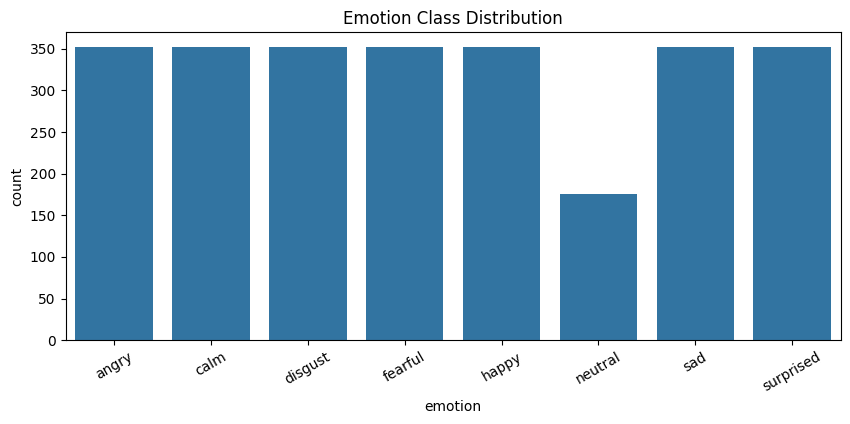

In [ ]:
# -----------------------------
# 7. Class distribution
# -----------------------------
plt.figure(figsize=(10, 4))
sns.countplot(x="emotion", data=df, order=sorted(df["emotion"].unique()))
plt.title("Emotion Class Distribution")
plt.xticks(rotation=30)
plt.show()

### Dataset-Level EDA
Explore duration distribution, actor balance, and per-emotion signal energy before any feature engineering.

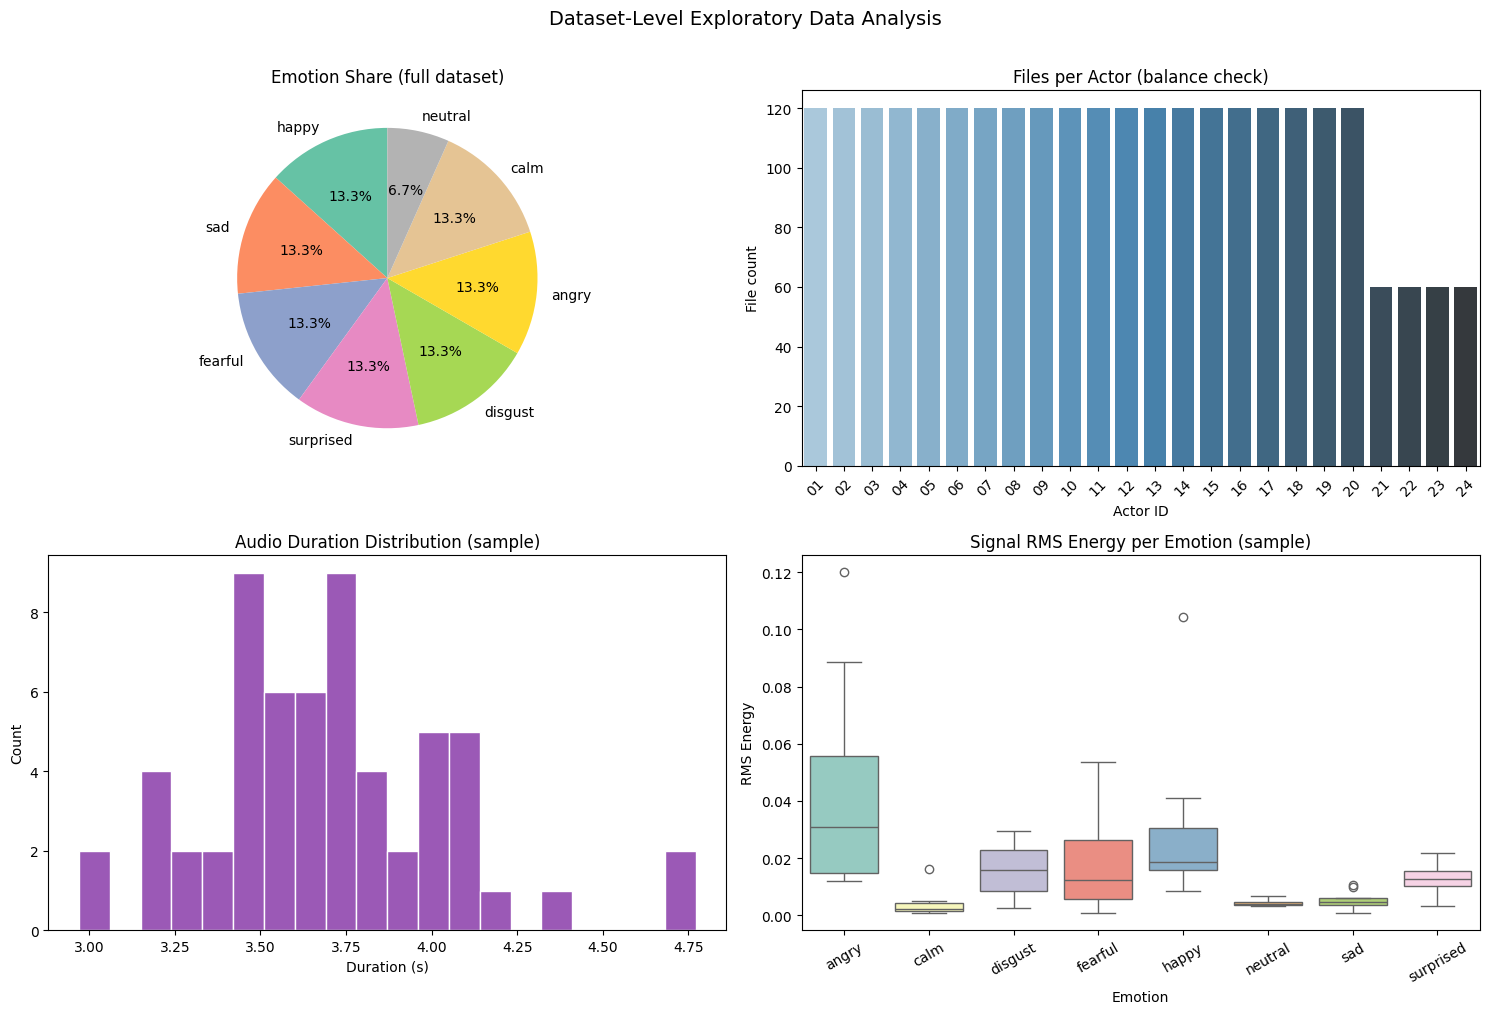

In [ ]:

import librosa, numpy as np, matplotlib.pyplot as plt, seaborn as sns

# Sample 60 files for quick EDA (full loop is slow without GPU)
eda_sample = df.sample(min(60, len(df)), random_state=42).copy()
durations, rms_vals = [], []

for _, row in eda_sample.iterrows():
    try:
        sig, sr = librosa.load(row["path"], sr=22050)
        durations.append(librosa.get_duration(y=sig, sr=sr))
        rms_vals.append(float(np.sqrt(np.mean(sig**2))))
    except:
        durations.append(np.nan); rms_vals.append(np.nan)

eda_sample["duration"]  = durations
eda_sample["rms_energy"] = rms_vals

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1 – Pie: emotion share
counts = df["emotion"].value_counts()
axes[0,0].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
              startangle=90, colors=sns.color_palette("Set2", len(counts)))
axes[0,0].set_title("Emotion Share (full dataset)")

# 2 – Actor file count (balance check)
actor_counts = df["actor"].value_counts().sort_index()
sns.barplot(x=actor_counts.index, y=actor_counts.values, ax=axes[0,1], palette="Blues_d")
axes[0,1].set_title("Files per Actor (balance check)")
axes[0,1].set_xlabel("Actor ID"); axes[0,1].set_ylabel("File count")
axes[0,1].tick_params(axis="x", rotation=45)

# 3 – Duration distribution
axes[1,0].hist(eda_sample["duration"].dropna(), bins=20, color="#9b59b6", edgecolor="white")
axes[1,0].set_title("Audio Duration Distribution (sample)")
axes[1,0].set_xlabel("Duration (s)"); axes[1,0].set_ylabel("Count")

# 4 – RMS energy per emotion
sns.boxplot(data=eda_sample, x="emotion", y="rms_energy", ax=axes[1,1], palette="Set3",
            order=sorted(eda_sample["emotion"].unique()))
axes[1,1].set_title("Signal RMS Energy per Emotion (sample)")
axes[1,1].set_xlabel("Emotion"); axes[1,1].set_ylabel("RMS Energy")
axes[1,1].tick_params(axis="x", rotation=30)

plt.suptitle("Dataset-Level Exploratory Data Analysis", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# -----------------------------
# 8. Audio augmentation functions
# -----------------------------
def add_noise(signal, noise_factor=0.005):
    noise = np.random.randn(len(signal))
    return signal + noise_factor * noise

def shift_signal(signal, shift_max=0.2):
    shift = int(np.random.uniform(-shift_max, shift_max) * len(signal))
    return np.roll(signal, shift)

def change_pitch(signal, sr, n_steps=2):
    return librosa.effects.pitch_shift(y=signal, sr=sr, n_steps=n_steps)

###Audio Augmentation Visualisation
Side-by-side comparison of original vs noise-augmented vs pitch-shifted waveforms and their MFCC matrices.

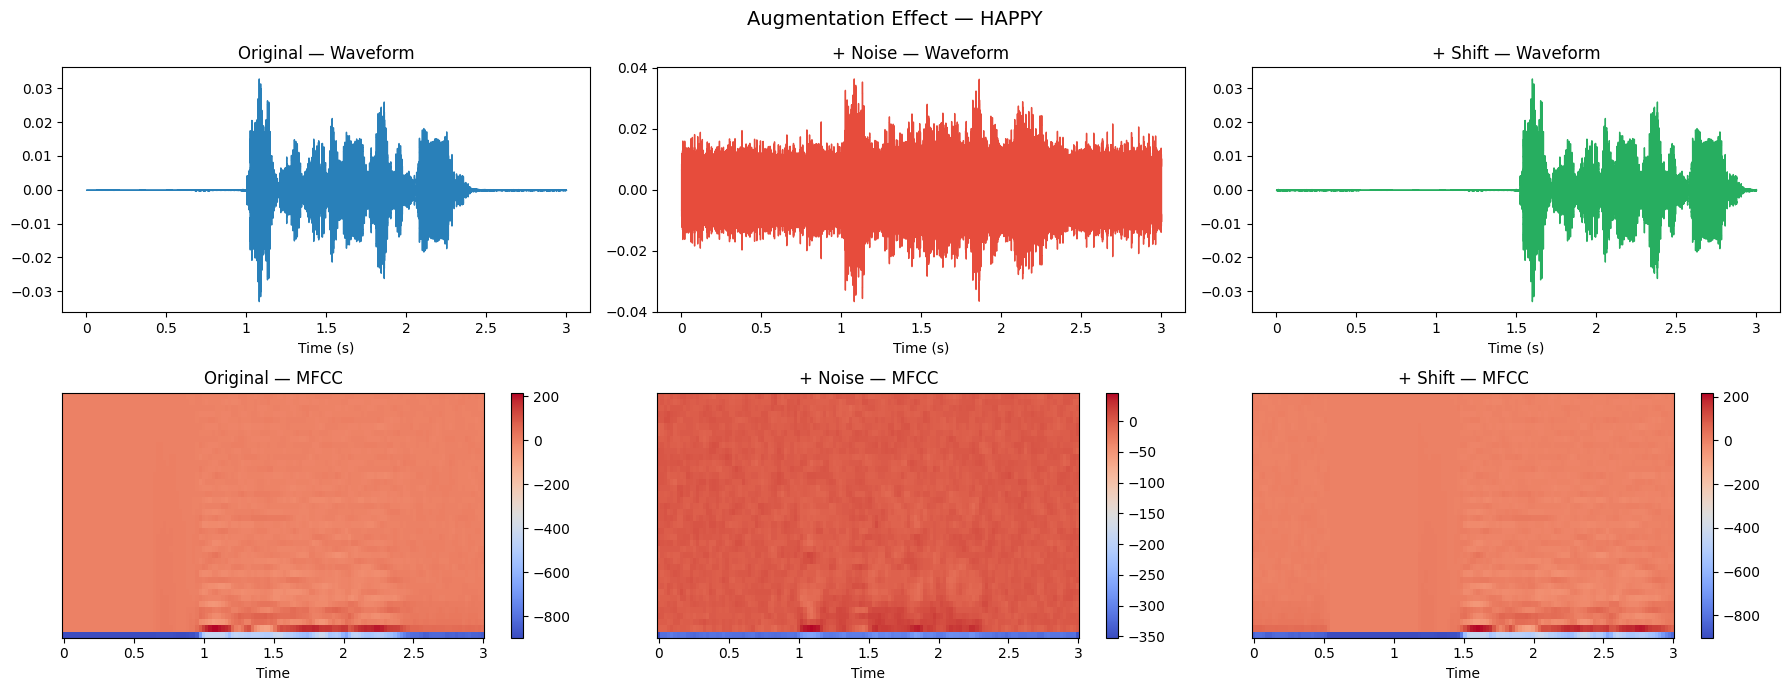

In [ ]:

import librosa, librosa.display, numpy as np, matplotlib.pyplot as plt

sample_path = df.iloc[0]["path"]
signal, sr  = librosa.load(sample_path, sr=22050, duration=3.0)

aug_noise   = add_noise(signal)
aug_shift   = shift_signal(signal)

variants    = [("Original", signal), ("+ Noise", aug_noise), ("+ Shift", aug_shift)]
colors      = ["#2980b9", "#e74c3c", "#27ae60"]

fig, axes = plt.subplots(2, 3, figsize=(18, 7))
fig.suptitle(f"Augmentation Effect — {df.iloc[0]['emotion'].upper()}", fontsize=14)

for col, (label, sig) in enumerate(variants):
    # Waveform
    librosa.display.waveshow(sig, sr=sr, ax=axes[0, col], color=colors[col])
    axes[0, col].set_title(f"{label} — Waveform")
    axes[0, col].set_xlabel("Time (s)")

    # MFCC
    mfcc = librosa.feature.mfcc(y=sig, sr=sr, n_mfcc=40)
    img  = librosa.display.specshow(mfcc, sr=sr, x_axis="time",
                                    ax=axes[1, col], cmap="coolwarm")
    axes[1, col].set_title(f"{label} — MFCC")
    plt.colorbar(img, ax=axes[1, col])

plt.tight_layout()
plt.show()


In [ ]:
# -----------------------------
# 9. Feature extraction settings
# -----------------------------
SAMPLE_RATE = 22050
DURATION = 3.0
SAMPLES_PER_TRACK = int(SAMPLE_RATE * DURATION)
N_MFCC = 40
MAX_PAD_LEN = 130   # fixed time frames for MFCC matrix

def load_audio_fixed(path, sr=SAMPLE_RATE, duration=DURATION):
    signal, sr = librosa.load(path, sr=sr)

    if len(signal) > SAMPLES_PER_TRACK:
        signal = signal[:SAMPLES_PER_TRACK]
    else:
        padding = SAMPLES_PER_TRACK - len(signal)
        signal = np.pad(signal, (0, padding), mode='constant')

    return signal, sr

def extract_mfcc(signal, sr, n_mfcc=N_MFCC, max_pad_len=MAX_PAD_LEN):
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
    mfcc = librosa.util.normalize(mfcc)

    if mfcc.shape[1] < max_pad_len:
        pad_width = max_pad_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_pad_len]

    return mfcc.T   # shape: (time, features)

#3) Rajagopala Rao Bandaru (35050526)

In [ ]:
import joblib
from tqdm.notebook import tqdm

# -----------------------------
# 10. Create dataset
# Original + optional augmentations
# -----------------------------
X = []
y = []
groups = []

USE_AUGMENTATION = True

def process_audio_file(row, use_augmentation, sample_rate, duration, n_mfcc, max_pad_len):
    try:
        signal, sr = load_audio_fixed(row["path"], sr=sample_rate, duration=duration)

        # Original
        mfcc = extract_mfcc(signal, sr, n_mfcc=n_mfcc, max_pad_len=max_pad_len)
        results = [(mfcc, row["emotion"], row["actor"])]

        if use_augmentation:
            # Noise augmentation
            aug1 = add_noise(signal)
            mfcc1 = extract_mfcc(aug1, sr, n_mfcc=n_mfcc, max_pad_len=max_pad_len)
            results.append((mfcc1, row["emotion"], row["actor"]))

            # Shift augmentation
            aug2 = shift_signal(signal)
            mfcc2 = extract_mfcc(aug2, sr, n_mfcc=n_mfcc, max_pad_len=max_pad_len)
            results.append((mfcc2, row["emotion"], row["actor"]))

        return results

    except Exception as e:
        # Log errors without stopping the whole process
        print(f"Error processing: {row['path']} -> {e}")
        return []

# Parallel processing of audio files
processed_data = joblib.Parallel(n_jobs=-1)(
    joblib.delayed(process_audio_file)(
        row,
        USE_AUGMENTATION,
        SAMPLE_RATE,
        DURATION,
        N_MFCC,
        MAX_PAD_LEN
    ) for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing audio files")
)

# Flatten the list of results and populate X, y, groups
for file_results in processed_data:
    for mfcc_data, emotion_label, actor_id in file_results:
        X.append(mfcc_data)
        y.append(emotion_label)
        groups.append(actor_id)

X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

print("Feature shape:", X.shape)   # (samples, time_steps, n_mfcc)
print("Labels shape:", y.shape)


Processing audio files:   0%|          | 0/2640 [00:00<?, ?it/s]

Feature shape: (7920, 130, 40)
Labels shape: (7920,)


In [ ]:
# -----------------------------
# 11. Encode labels
# -----------------------------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print("Classes:", list(label_encoder.classes_))


Classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]


###MFCC Feature Space — t-SNE Embedding
2D t-SNE projection of mean-pooled MFCC vectors, coloured by emotion, to check class separability before training.

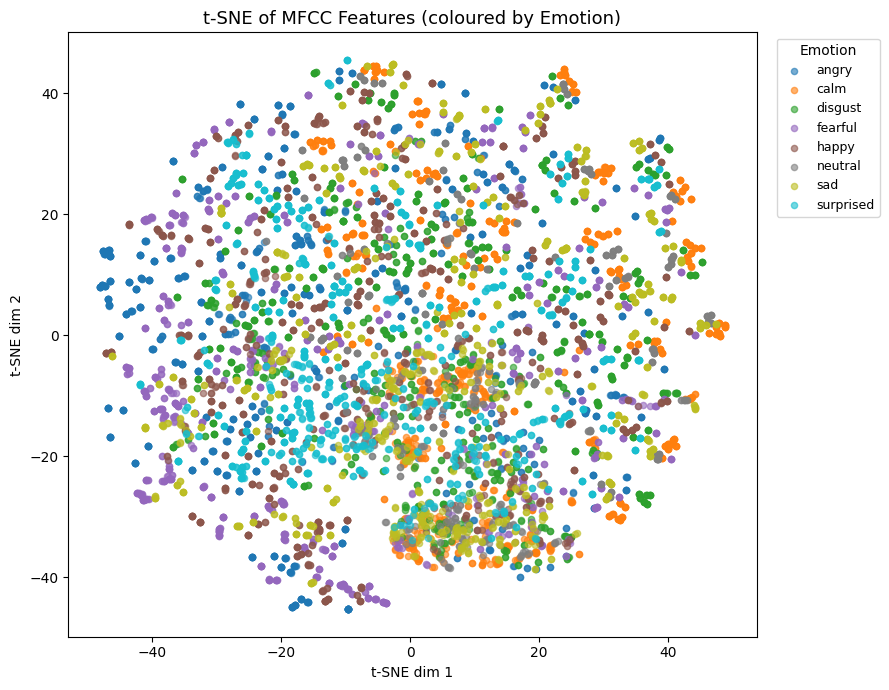

In [ ]:

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt, numpy as np

# Mean-pool time dimension: (N, time, 40) → (N, 40)
X_flat   = X.mean(axis=1)
X_scaled = StandardScaler().fit_transform(X_flat)
X_pca    = PCA(n_components=min(30, X_scaled.shape[1]), random_state=42).fit_transform(X_scaled)
X_tsne   = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500).fit_transform(X_pca)

palette  = plt.cm.get_cmap("tab10", len(np.unique(y)))
fig, ax  = plt.subplots(figsize=(9, 7))

for i, emotion in enumerate(np.unique(y)):
    mask = y == emotion
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               label=emotion, alpha=0.6, s=20, color=palette(i))

ax.set_title("t-SNE of MFCC Features (coloured by Emotion)", fontsize=13)
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.legend(title="Emotion", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
# -----------------------------
# 12. Group-based split by actor
# avoids leakage across same actor
# -----------------------------
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss1.split(X, y_encoded, groups=groups))

X_train_full, X_test = X[train_idx], X[test_idx]
y_train_full, y_test = y_encoded[train_idx], y_encoded[test_idx]
groups_train_full = groups[train_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx2, val_idx = next(gss2.split(X_train_full, y_train_full, groups=groups_train_full))

X_train, X_val = X_train_full[train_idx2], X_train_full[val_idx]
y_train, y_val = y_train_full[train_idx2], y_train_full[val_idx]

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (4680, 130, 40) (4680,)
Val  : (1440, 130, 40) (1440,)
Test : (1800, 130, 40) (1800,)


In [ ]:
# -----------------------------
# 13. Class weights for imbalance
# -----------------------------
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {i: weights[i] for i in range(len(classes))}
print("Class weights:", class_weights)


Class weights: {0: np.float64(0.9375), 1: np.float64(0.9375), 2: np.float64(0.9375), 3: np.float64(0.9375), 4: np.float64(0.9375), 5: np.float64(1.875), 6: np.float64(0.9375), 7: np.float64(0.9375)}


#4) Ashiq shaik (35033254)

In [ ]:
# -----------------------------
# 14. Build CNN + BiLSTM model
# -----------------------------
input_shape = (X_train.shape[1], X_train.shape[2])

inputs = Input(shape=input_shape)

x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.3)(x)

x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(32, return_sequences=True))(x)
x = Dropout(0.3)(x)

x = GlobalAveragePooling1D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 130, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 130, 64)        │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 130, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 65, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 65, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 65, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 65, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32, 64)         │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,600 (713.28 KB)

 Trainable params: 182,216 (711.78 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# -----------------------------
# 15. Callbacks
# -----------------------------
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        "best_speech_emotion_model.keras",
        monitor='val_loss',
        save_best_only=True
    )
]

In [ ]:
# -----------------------------
# 16. Train model
# -----------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.3135 - loss: 1.7156 - val_accuracy: 0.1333 - val_loss: 3.0693 - learning_rate: 0.0010
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5457 - loss: 1.2313 - val_accuracy: 0.1333 - val_loss: 4.1504 - learning_rate: 0.0010
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6761 - loss: 0.9188 - val_accuracy: 0.1646 - val_loss: 4.4868 - learning_rate: 0.0010
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7397 - loss: 0.7268 - val_accuracy: 0.3021 - val_loss: 2.9608 - learning_rate: 0.0010
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7855 - loss: 0.6099 - val_accuracy: 0.4472 - val_loss: 1.8953 - learning_rate: 0.0010
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8241 - loss: 0.4962 - val_accuracy: 0.4875 - val_loss: 2.0215 - learning_rate: 0.0010
Epoch 7/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8530 - loss: 0

#5) Mohammed Suleman (35049043)

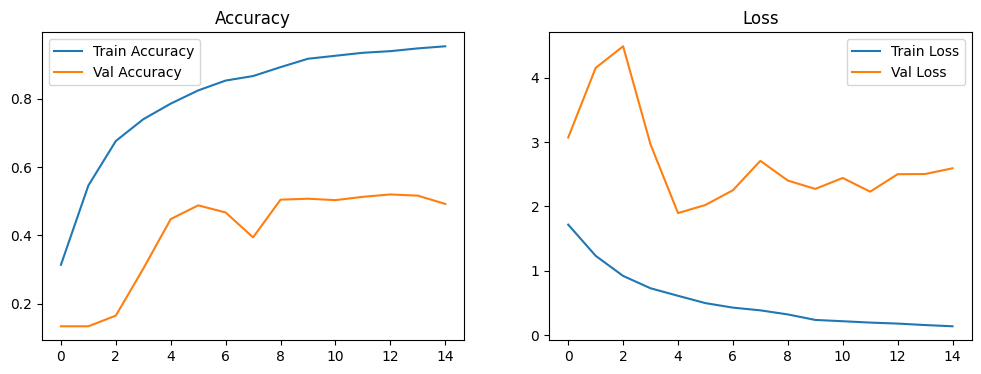

In [ ]:
# -----------------------------
# 17. Plot training curves
# -----------------------------
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [ ]:
# -----------------------------
# 18. Evaluate on test set
# -----------------------------
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average='weighted'
)

print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall   : {recall:.4f}")
print(f"Test F1-Score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Test Accuracy : 0.3400
Test Precision: 0.4720
Test Recall   : 0.3400
Test F1-Score : 0.3108

Classification Report:

              precision    recall  f1-score   support

       angry       0.68      0.58      0.62       240
        calm       0.60      0.12      0.20       240
     disgust       0.30      0.47      0.36       240
     fearful       0.33      0.44      0.38       240
       happy       0.60      0.05      0.09       240
     neutral       0.12      0.01      0.02       120
         sad       0.21      0.67      0.32       240
   surprised       0.76      0.22      0.34       240

    accuracy                           0.34      1800
   macro avg       0.45      0.32      0.29      1800
weighted avg       0.47      0.34      0.31      1800



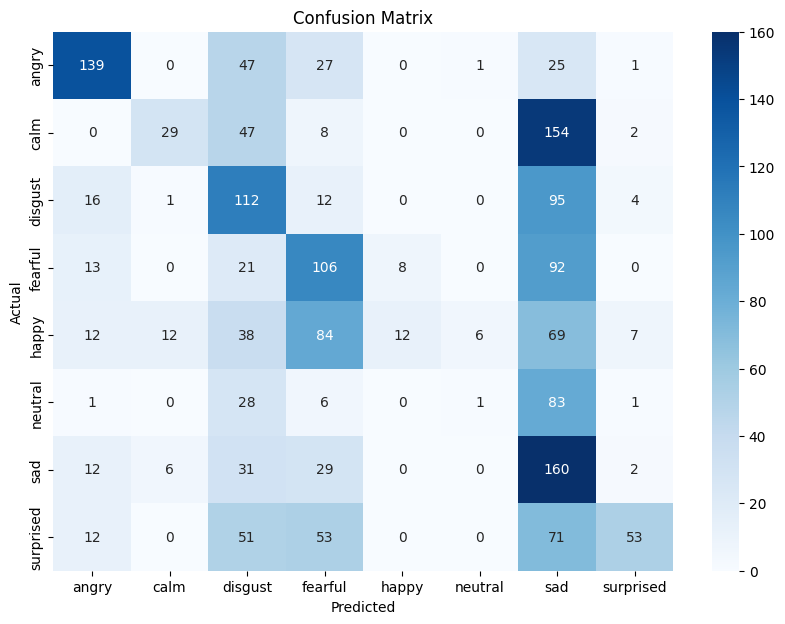

In [ ]:
# -----------------------------
# 19. Confusion matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# -----------------------------
# 20. Save label classes
# -----------------------------
np.save("speech_label_classes.npy", label_encoder.classes_)
print("Model and label classes saved.")

Model and label classes saved.


In [ ]:
# -----------------------------
# 21. Single file prediction function
# -----------------------------
def predict_emotion(file_path, model, label_encoder):
    signal, sr = load_audio_fixed(file_path)
    mfcc = extract_mfcc(signal, sr)
    mfcc = np.expand_dims(mfcc, axis=0)  # batch dimension

    pred_probs = model.predict(mfcc, verbose=0)
    pred_idx = np.argmax(pred_probs, axis=1)[0]
    pred_label = label_encoder.inverse_transform([pred_idx])[0]

    return pred_label, pred_probs[0]

# Example:
sample_file = df.iloc[0]["path"]
pred_label, pred_probs = predict_emotion(sample_file, model, label_encoder)
print("Sample file:", sample_file)
print("Predicted emotion:", pred_label)


Sample file: /content/drive/MyDrive/RAVDESS Emotional dataset/Actor_09/03-01-03-01-02-01-09.wav
Predicted emotion: sad


###Sample Prediction Showcase
Run the trained model on 10 random test samples, display actual vs predicted with confidence bars, and show a full class probability breakdown for the first sample.

#    Actual       Predicted    Confidence  Match?
-------------------------------------------------------
1    disgust      fearful           37.4%  ✗
2    fearful      fearful           92.8%  ✓
3    sad          sad               84.5%  ✓
4    calm         sad               79.3%  ✗
5    calm         sad               57.2%  ✗
6    sad          sad               78.1%  ✓
7    disgust      sad               79.9%  ✗
8    surprised    sad               45.1%  ✗
9    surprised    sad               53.5%  ✗
10   fearful      disgust           75.4%  ✗


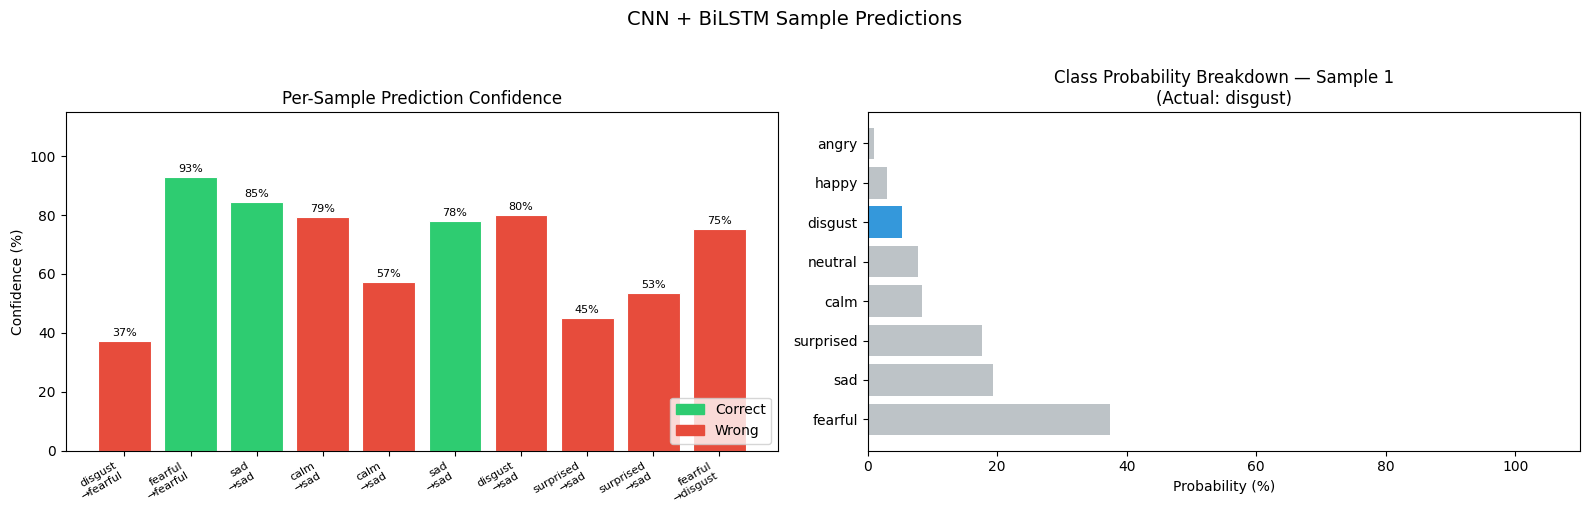


Sample accuracy : 3/10 = 30%
Mean confidence : 68.3%


In [ ]:

import random, numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches

# Pick up to 10 random test samples
rng      = np.random.default_rng(42)
idx      = rng.choice(len(X_test), size=min(10, len(X_test)), replace=False)
X_sample = X_test[idx]
y_actual_enc = y_test[idx]
y_actual = label_encoder.inverse_transform(y_actual_enc)

pred_probs  = model.predict(X_sample, verbose=0)
pred_enc    = np.argmax(pred_probs, axis=1)
y_predicted = label_encoder.inverse_transform(pred_enc)
confidence  = np.max(pred_probs, axis=1)

# ── tabular summary ──────────────────────────────────────────
print(f"{'#':<4} {'Actual':<12} {'Predicted':<12} {'Confidence':>10}  Match?")
print("-" * 55)
for i, (act, pred, c) in enumerate(zip(y_actual, y_predicted, confidence)):
    mark = "✓" if act == pred else "✗"
    print(f"{i+1:<4} {act:<12} {pred:<12} {c*100:>9.1f}%  {mark}")

# ── bar chart: confidence per sample ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ["#2ecc71" if a == p else "#e74c3c"
          for a, p in zip(y_actual, y_predicted)]

bars = axes[0].bar(range(len(y_actual)), confidence * 100,
                   color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_xticks(range(len(y_actual)))
axes[0].set_xticklabels(
    [f"{a}\n→{p}" for a, p in zip(y_actual, y_predicted)],
    fontsize=8, rotation=30, ha="right"
)
axes[0].set_ylim(0, 115)
axes[0].set_ylabel("Confidence (%)")
axes[0].set_title("Per-Sample Prediction Confidence")
for bar, c in zip(bars, confidence):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{c*100:.0f}%", ha="center", va="bottom", fontsize=8)
axes[0].legend(handles=[
    mpatches.Patch(color="#2ecc71", label="Correct"),
    mpatches.Patch(color="#e74c3c", label="Wrong")
], loc="lower right")

# ── probability breakdown for first sample ────────────────────
first_prob = pred_probs[0]
emotions   = label_encoder.classes_
sorted_idx = np.argsort(first_prob)[::-1]
bar_colors = ["#3498db" if emotions[j] == y_actual[0] else "#bdc3c7"
              for j in sorted_idx]
axes[1].barh([emotions[j] for j in sorted_idx],
             [first_prob[j] * 100 for j in sorted_idx],
             color=bar_colors)
axes[1].set_xlabel("Probability (%)")
axes[1].set_xlim(0, 110)
axes[1].set_title(f"Class Probability Breakdown — Sample 1\n(Actual: {y_actual[0]})")

plt.suptitle("CNN + BiLSTM Sample Predictions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

n_correct = sum(a == p for a, p in zip(y_actual, y_predicted))
print(f"\nSample accuracy : {n_correct}/{len(y_actual)} = {n_correct/len(y_actual)*100:.0f}%")
print(f"Mean confidence : {np.mean(confidence)*100:.1f}%")


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/speech_emotion_model"

import os
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_SAVE_PATH = os.path.join(SAVE_DIR, "best_speech_emotion_model.keras")
LABELS_SAVE_PATH = os.path.join(SAVE_DIR, "speech_label_classes.npy")

model.save(MODEL_SAVE_PATH)
print("Model saved at:", MODEL_SAVE_PATH)

import numpy as np

np.save(LABELS_SAVE_PATH, label_encoder.classes_)
print("Labels saved at:", LABELS_SAVE_PATH)

import os

print(os.path.exists(MODEL_SAVE_PATH))
print(os.path.exists(LABELS_SAVE_PATH))

Model saved at: /content/drive/MyDrive/speech_emotion_model/best_speech_emotion_model.keras
Labels saved at: /content/drive/MyDrive/speech_emotion_model/speech_label_classes.npy
True
True


In [ ]:
import gradio as gr
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
import librosa

# =========================
# PATHS
# =========================
FACE_MODEL_PATH = "/content/drive/MyDrive/face_csv_emotion_model/best_face_emotion_model.pkl"
LABEL_ENCODER_PATH = "/content/drive/MyDrive/face_csv_emotion_model/label_encoder.pkl"
FEATURE_COLUMNS_PATH = "/content/drive/MyDrive/face_csv_emotion_model/feature_columns.pkl"

AUDIO_MODEL_PATH = "/content/drive/MyDrive/speech_emotion_model/best_speech_emotion_model.keras"
AUDIO_LABELS_PATH = "/content/drive/MyDrive/speech_emotion_model/speech_label_classes.npy"

# =========================
# LOAD MODELS
# =========================
face_model = joblib.load(FACE_MODEL_PATH)
label_encoder_face = joblib.load(LABEL_ENCODER_PATH)
feature_columns = joblib.load(FEATURE_COLUMNS_PATH)

audio_model = tf.keras.models.load_model(AUDIO_MODEL_PATH)
audio_classes = np.load(AUDIO_LABELS_PATH)

# =========================
# FACE CSV FEATURE EXTRACTION
# =========================
def extract_features_from_csv(filepath):
    df = pd.read_csv(filepath)
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.fillna(df.median(numeric_only=True)).fillna(0)

    feature_dict = {}
    for col in df.columns:
        values = df[col].values.astype(np.float32)
        feature_dict[f"{col}_mean"] = np.mean(values)
        feature_dict[f"{col}_std"] = np.std(values)
        feature_dict[f"{col}_min"] = np.min(values)
        feature_dict[f"{col}_max"] = np.max(values)
        feature_dict[f"{col}_median"] = np.median(values)

    return feature_dict

def predict_face_csv(csv_file):
    feats = extract_features_from_csv(csv_file)
    row = pd.DataFrame([feats])

    for col in feature_columns:
        if col not in row.columns:
            row[col] = 0

    row = row[feature_columns]
    pred = face_model.predict(row)[0]
    return label_encoder_face.inverse_transform([pred])[0]

# =========================
# AUDIO
# =========================
def load_audio_fixed(path, sr=22050, duration=3):
    signal, sr = librosa.load(path, sr=sr)
    max_len = sr * duration
    if len(signal) > max_len:
        signal = signal[:max_len]
    else:
        signal = np.pad(signal, (0, max_len - len(signal)))
    return signal, sr

def extract_mfcc(signal, sr):
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
    if mfcc.shape[1] < 130:
        mfcc = np.pad(mfcc, ((0,0),(0,130-mfcc.shape[1])))
    else:
        mfcc = mfcc[:, :130]
    return mfcc.T

def predict_audio(audio_path):
    signal, sr = load_audio_fixed(audio_path)
    mfcc = extract_mfcc(signal, sr)
    mfcc = np.expand_dims(mfcc, axis=0)
    preds = audio_model.predict(mfcc, verbose=0)
    return audio_classes[np.argmax(preds)]

# =========================
# FINAL PREDICTION
# =========================
def predict(csv_file, audio_file):
    if csv_file is None or audio_file is None:
        return "Please upload both CSV and WAV files"

    face_emotion = predict_face_csv(csv_file)
    audio_emotion = predict_audio(audio_file)

    if face_emotion == audio_emotion:
        final = f"{face_emotion}"
    else:
        final = f"Face: {face_emotion} | Audio: {audio_emotion}"

    return f"""
FACE EMOTION: {face_emotion}

AUDIO EMOTION: {audio_emotion}

FINAL RESULT: {final}
"""

# =========================
# CUSTOM CSS (BIG + COLORFUL)
# =========================
css = """
body {
    background: linear-gradient(to right, #1e3c72, #2a5298);
}
h1 {
    text-align: center;
    color: white;
    font-size: 42px !important;
}
.gr-button {
    background-color: #ff9800 !important;
    color: white !important;
    font-size: 18px !important;
}
textarea {
    font-size: 20px !important;
    font-weight: bold;
}
"""

# =========================
# UI LAYOUT
# =========================
with gr.Blocks(css=css) as demo:

    gr.Markdown("# Multimodal Emotion Detection System")

    with gr.Row():
        with gr.Column():
            csv_input = gr.File(label="Upload Face CSV")
        with gr.Column():
            audio_input = gr.Audio(type="filepath", label="Upload Speech (.wav)")

    predict_btn = gr.Button("Predict Emotion")

    output = gr.Textbox(label="Results", lines=8)

    predict_btn.click(fn=predict, inputs=[csv_input, audio_input], outputs=output)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5e61c50dca10dcdea9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
